In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parents[1]  # importing functions from other folders

sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
from _data.data_utils import read_in
from _fitting.fitting_utils import abbrev_stat
from _fitting.model_utils_smooth import *
# from _fitting.fitting_utils import hist_plot, CI_plot, CI_plot_alt, CI_plot_both, plot_posteriors_side_by_side, plot_spline_Bknots
import pymc as pm
import pymc.math as pmm
import arviz as az
from patsy import dmatrix
import nutpie
import time
from IPython.display import display
from pymc.variational.callbacks import CheckParametersConvergence
import io
import base64
import re
import pytensor.tensor as pt
from pytensor.gradient import disconnected_grad
from scipy.sparse.linalg import eigsh
from matplotlib.colors import Normalize, TwoSlopeNorm, to_rgba

az.style.use("arviz-darkgrid")

if '___laptop' in os.listdir('../../'):

    # laptop folder
    folder = "../../../_data/p-dengue/"
elif '___server' in os.listdir('../../'):

    # server folder
    folder = "../../../../../../data/lucaratzinger_data/p_dengue/"

%matplotlib inline
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
model_fits_folder = os.path.join(folder, "model_fits/")
run_folders = ["a2_201601_201912[smooth_s1|6_selection]"]

In [3]:
data_settings = {'admin':2, 'max_lag':6, 'start_year':2016, 'start_month':1, 'end_year':2019, 'end_month':12}
_data = read_in(folder, **data_settings, standardise=True, dropna=True, celsius=True, tp_log=True)
statistics = _data.columns.tolist()
# that start with t2m, rh, tp
statistics = [name for name in statistics if name.startswith(('t2m','rh','tp'))]
# that contains 'pop_weighted'
statistics = [name for name in statistics if 'pop_weighted' in name]
# if it contains 'tp' then it should contain 'log('
statistics = [name for name in statistics if not (name.startswith('tp') and 'log(' not in name)]
lags = [0, 1, 3, 5]
statistics = [stat for stat in statistics if any(f"({lag})" in stat for lag in lags)]
statistics.sort()
abbrev_statistics = [abbrev_stat(stat) for stat in statistics]

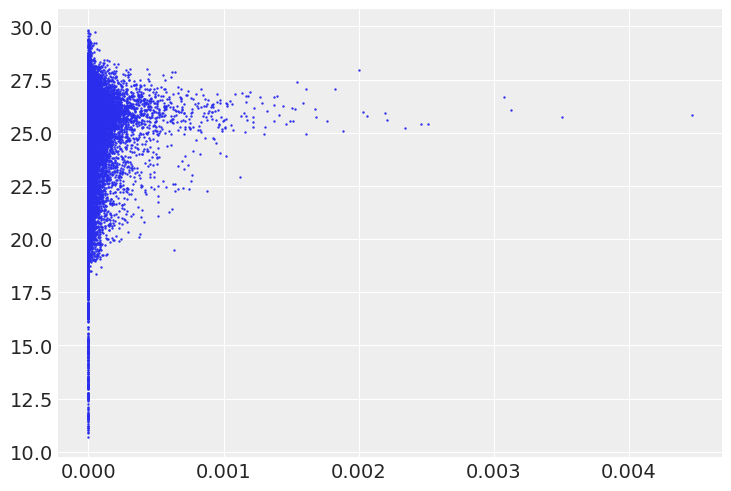

In [54]:
plt.scatter(_data['rate'], _data['t2m_mean_pop_weighted(0)'], s=0.5)
plt.show()

In [4]:
def parse_name(name):
        p_match = re.search(r'p=([\d.]+)', name)
        k_match = re.search(r'__knots\((\d+)', name)
        # s_match = re.search(r'std=(True|False)', name)
        stat_match = re.search(r'\[([a-zA-Z0-9_()]+)\]', name)
        return {
            'p': float(p_match.group(1)) if p_match else None,
            'num_knots': int(k_match.group(1)) if k_match else None,
            # 'std': s_match.group(1) == 'True' if s_match else None,
            'stat_name': stat_match.group(1) if stat_match else None,
        }

In [36]:
model_summaries = {}
for run in run_folders:
    run_folder = os.path.join(model_fits_folder, run)   
    outputs_folder = os.path.join(run_folder, "outputs")
    for file in os.listdir(outputs_folder)[:]:
        summary_path = os.path.join(os.path.join(outputs_folder, file), "summary.csv")
        if os.path.exists(summary_path):
            meta = parse_name(file)
            summary = pd.read_csv(summary_path)
            n_bad_rhat = summary[summary['r_hat'] >= 1.02].shape[0]
            bad_rhat = n_bad_rhat > 0
            n_low_ess_bulk = summary[summary['ess_bulk'] < 500].shape[0] > 0
            low_ess_bulk = n_low_ess_bulk > 0
            n_low_ess_tail = summary[summary['ess_tail'] < 500].shape[0] > 0
            low_ess_tail = n_low_ess_tail > 0
            model_summaries[file] = {
                'summary': summary,
                'bad_rhat': bad_rhat,
                'low_ess_bulk': low_ess_bulk,
                'low_ess_tail': low_ess_tail,
                'p': meta['p'],
                'num_knots': meta['num_knots'],
                'stat_name': meta['stat_name'],
            }

In [37]:
model_summaries_df = pd.DataFrame({
    'model': list(model_summaries.keys()),
    'p': [model_summaries[key]['p'] for key in model_summaries.keys()],
    'num_knots': [model_summaries[key]['num_knots'] for key in model_summaries.keys()],
    'stat_name': [model_summaries[key]['stat_name'] for key in model_summaries.keys()],
    'bad_rhat': [model_summaries[key]['bad_rhat'] for key in model_summaries.keys()],
    'low_ess_bulk': [model_summaries[key]['low_ess_bulk'] for key in model_summaries.keys()],
    'low_ess_tail': [model_summaries[key]['low_ess_tail'] for key in model_summaries.keys()],
})

In [38]:
model_summaries_df

,model,p,num_knots,stat_name,bad_rhat,low_ess_bulk,low_ess_tail
0,"[t2m_mean_p(5)]__pen(o2,p=5.0)__knots(20,equis...",5.0,20,t2m_mean_p(5),False,False,False
1,"[rh_mean_p(5)]__pen(o2,p=16.0)__knots(15,equis...",16.0,15,rh_mean_p(5),False,False,False
2,"[tp_24hmean_log_p(1)]__pen(o2,p=20.0)__knots(2...",20.0,25,tp_24hmean_log_p(1),False,False,False
3,"[rh_mean_p(5)]__pen(o2,p=1000.0)__knots(50,equ...",1000.0,50,rh_mean_p(5),False,False,False
4,"[tp_24hmean_log_p(3)]__pen(o2,p=5.0)__knots(10...",5.0,10,tp_24hmean_log_p(3),False,False,False
...,...,...,...,...,...,...,...
2395,"[t2m_mean_p(1)]__pen(o2,p=1000.0)__knots(15,eq...",1000.0,15,t2m_mean_p(1),False,False,False
2396,"[rh_mean_p(1)]__pen(o2,p=7.5)__knots(40,equisp...",7.5,40,rh_mean_p(1),False,False,False
2397,"[t2m_max_p(5)]__pen(o2,p=2.5)__knots(30,equisp...",2.5,30,t2m_max_p(5),False,False,False
2398,"[t2m_mean_p(1)]__pen(o2,p=25.0)__knots(5,equis...",25.0,5,t2m_mean_p(1),False,False,False


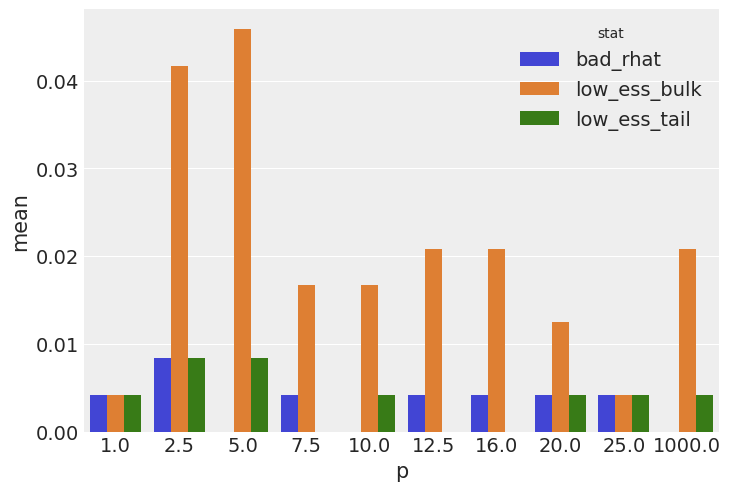

In [39]:
grouped = model_summaries_df.groupby('p').agg({
    'bad_rhat': 'mean',
    'low_ess_bulk': 'mean',
    'low_ess_tail': 'mean',
}).reset_index()

p_values = grouped['p']
stats = ['bad_rhat', 'low_ess_bulk', 'low_ess_tail']

melted = grouped.melt(id_vars='p', value_vars=stats, var_name='stat', value_name='mean')
sns.barplot(data=melted, x='p', hue='stat', y='mean')
plt.show()

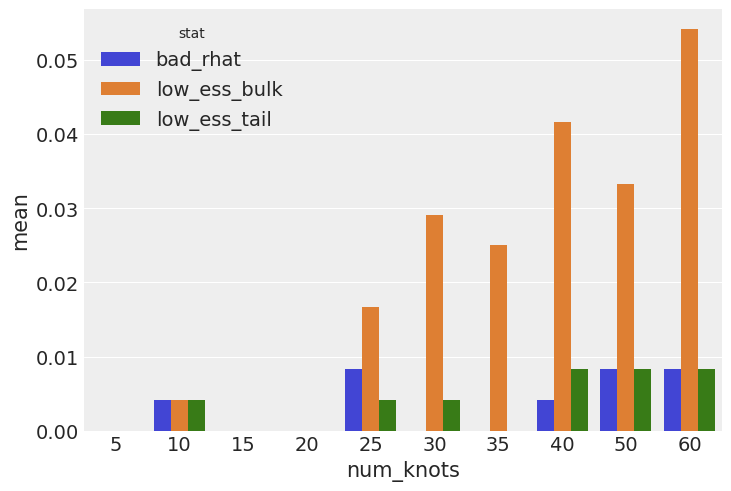

In [40]:
grouped = model_summaries_df.groupby('num_knots').agg({
    'bad_rhat': 'mean',
    'low_ess_bulk': 'mean',
    'low_ess_tail': 'mean',
}).reset_index()

nk_values = grouped['num_knots']
stats = ['bad_rhat', 'low_ess_bulk', 'low_ess_tail']

melted = grouped.melt(id_vars='num_knots', value_vars=stats, var_name='stat', value_name='mean')
sns.barplot(data=melted, x='num_knots', hue='stat', y='mean')
plt.show()

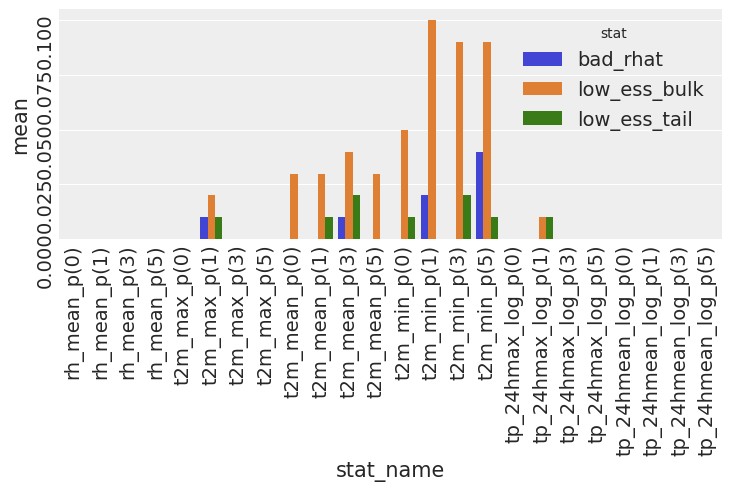

In [41]:
grouped = model_summaries_df.groupby('stat_name').agg({
    'bad_rhat': 'mean',
    'low_ess_bulk': 'mean',
    'low_ess_tail': 'mean',
}).reset_index()

sn_values = grouped['stat_name']
stats = ['bad_rhat', 'low_ess_bulk', 'low_ess_tail']

melted = grouped.melt(id_vars='stat_name', value_vars=stats, var_name='stat', value_name='mean')
sns.barplot(data=melted, x='stat_name', hue='stat', y='mean')
plt.tick_params(rotation=90)
plt.show()

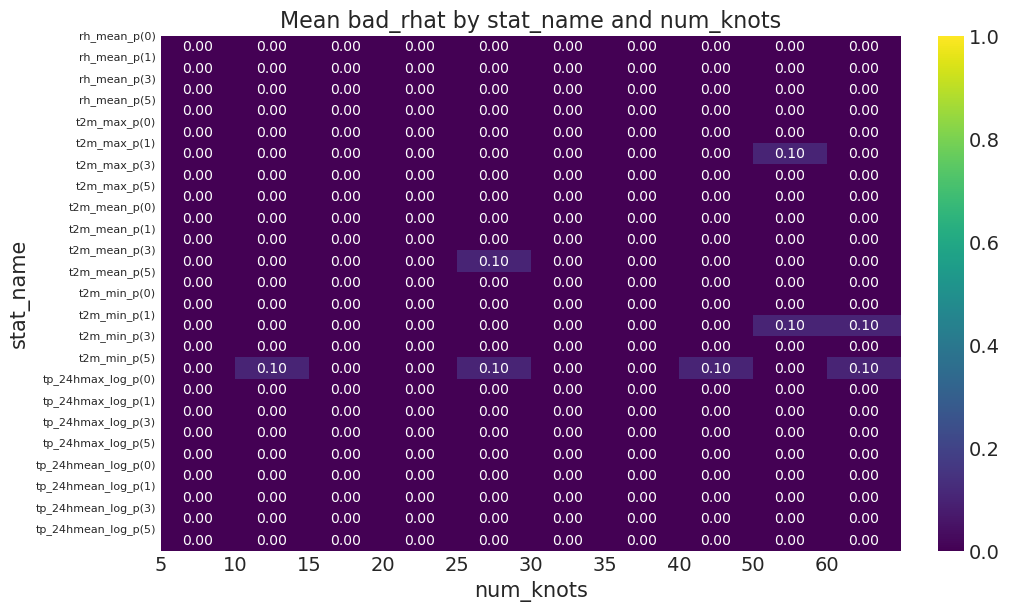

In [51]:
metric = 'bad_rhat'  # or 'low_ess_bulk', 'low_ess_tail'

# Step 1: group by both dimensions
grouped = model_summaries_df.groupby(['stat_name', 'num_knots']).agg({
    'bad_rhat': 'mean',
    'low_ess_bulk': 'mean',
    'low_ess_tail': 'mean',
}).reset_index()

# Step 2: function to plot chosen metric
def plot_heatmap(grouped, metric):
    pivot = grouped.pivot(
        index='stat_name',
        columns='num_knots',
        values=metric
    )
    
    fig, ax = plt.subplots(figsize=(10, 6))

    vmin, vmax = 0, 1  # since these are proportions
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="viridis", vmin=vmin, vmax=vmax)

    ax.set_title(f"Mean {metric} by stat_name and num_knots")
    ax.set_xlabel("num_knots")
    ax.set_ylabel("stat_name")

    # Set tick labels
    ax.set_yticks(range(len(pivot.index)), labels=pivot.index, fontsize=8)

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)

    plt.show()

# Step 3: choose what to plot
plot_heatmap(grouped, metric)        # or 'low_ess_bulk', 'low_ess_tail'